In [4]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, sys
sys.path.append(r'C:\Users\Win11Pro\Desktop\KDT-14\[7]_CVISION')
from cv_utils import *

In [8]:
# Canny 예제 edge 검출
img = cv2.imread('./Data/images/taekwon_v.jpg')

edges = cv2.Canny(img, 100, 200)

cv2.imshow('origin', img)
cv2.imshow('canny', edges)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
# 역투영 예제
win_name = 'back_projection'
img = cv2.imread('./Data/images/19752893c8538724f.jpg')
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
draw = img.copy()

def masking(bp, win_name):
    disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    cv2.filter2D(bp,-1,disc,bp)
    _, mask = cv2.threshold(bp, 1, 255, cv2.THRESH_BINARY)
    result = cv2.bitwise_and(img, img, mask=mask)
    cv2.imshow(win_name, result)

def backProject_manual(hist_roi):
    hist_img = cv2.calcHist([hsv_img], [0,1], None, [180,256], [0,180,0,256])
    hist_rate = hist_roi / (hist_img + 1)

    h, s, v = cv2.split(hsv_img)
    bp = hist_rate[h.ravel(), s.ravel()]
    bp = np.minimum(bp, 1)
    bp = bp.reshape(hsv_img.shape[:2])
    cv2.normalize(bp,bp, 0, 255, cv2.NORM_MINMAX)
    bp = bp.astype(np.uint8)
    masking(bp, 'result_manual')

def backProject_Cv(hist_roi):
    bp = cv2.calcBackProject([hsv_img], [0, 1], hist_roi, [0 , 180, 0, 256], 1)
    masking(bp,'result_cv')

(x,y,w,h) = cv2.selectROI(win_name, img, False)
if w > 0 and h > 0:
    roi = img[y:y+h, x:x+w]
    cv2.rectangle(draw, (x,y), (x+w, y+h), (0,0,255), 2)

    hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    hist_roi = cv2.calcHist([hsv_roi], [0,1], None, [180, 256], [0, 180, 0, 256])
    backProject_manual(hist_roi)
    backProject_Cv(hist_roi)

cv2.imshow(win_name, draw)
cv2.waitKey()
cv2.destroyAllWindows()

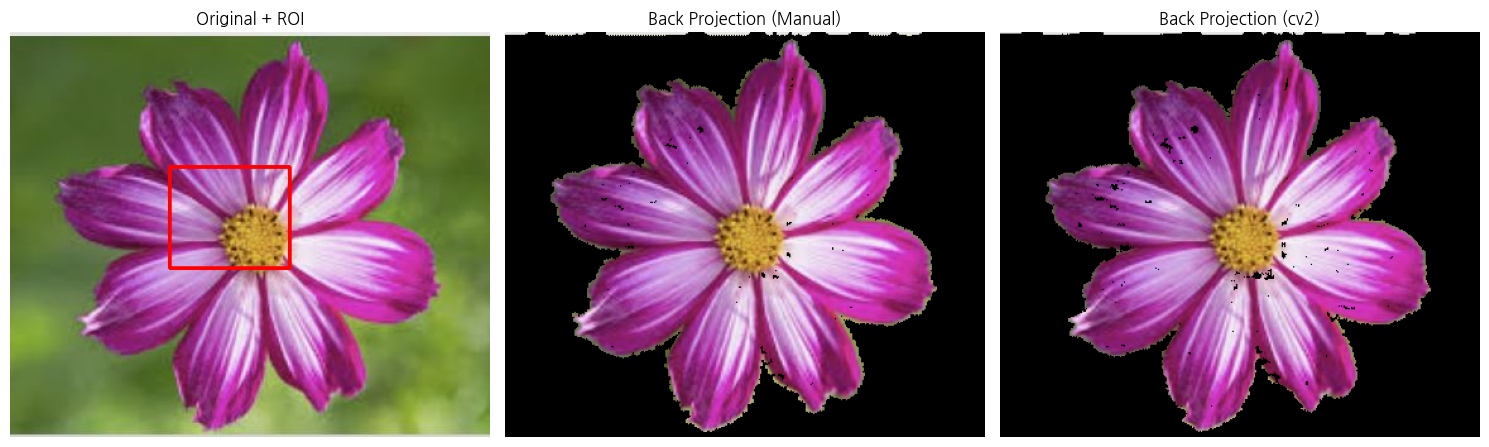

In [89]:
img = cv2.imread('./Data/images/flower.jpg')
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h_img, w_img = img.shape[:2]
x, y, w, h = w_img//3, h_img//3, w_img//4, h_img//4
roi = img[y:y+h, x:x+w]

hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
hist_roi = cv2.calcHist([hsv_roi], [0,1], None, [180,256], [0,180,0,256])

def get_mask(bp):
    disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    cv2.filter2D(bp, -1, disc, bp)
    _, mask = cv2.threshold(bp, 1, 255, cv2.THRESH_BINARY)
    return cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

def backProject_manual(hist_roi):
    hist_img = cv2.calcHist([hsv_img], [0,1], None, [180,256], [0,180,0,256])
    hist_rate = hist_roi / (hist_img + 1)
    h, s, v = cv2.split(hsv_img)
    bp = hist_rate[h.ravel(), s.ravel()]
    bp = np.minimum(bp, 1).reshape(hsv_img.shape[:2])
    cv2.normalize(bp, bp, 0, 255, cv2.NORM_MINMAX)
    return get_mask(bp.astype(np.uint8))

def backProject_cv(hist_roi):
    bp = cv2.calcBackProject([hsv_img], [0,1], hist_roi, [0,180,0,256], 1)
    return get_mask(bp)

result_manual = backProject_manual(hist_roi)
result_cv     = backProject_cv(hist_roi)

draw = img_rgb.copy()
cv2.rectangle(draw, (x,y), (x+w, y+h), (255,0,0), 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(draw);          axes[0].set_title('Original + ROI')
axes[1].imshow(result_manual); axes[1].set_title('Back Projection (Manual)')
axes[2].imshow(result_cv);     axes[2].set_title('Back Projection (cv2)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

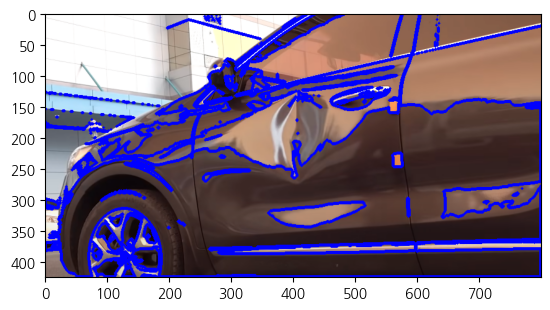

In [6]:
img = cv2.imread('./Data/images/car2.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, th = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)

contours, hierachy = cv2.findContours(th, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
# print(len(contours), hierachy)

cv2.drawContours(img, contours, -1, (0,0,255), 4)
plt.imshow(img)

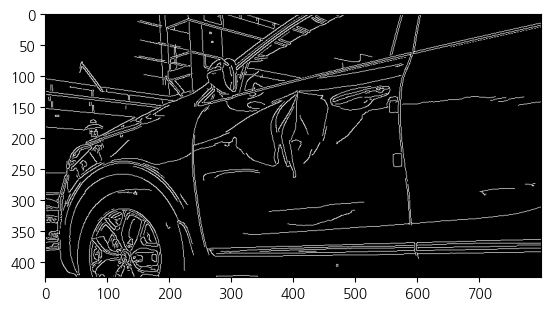

In [45]:
img = cv2.imread('./Data/images/car2.png')
# img = cv2.imread('./Data/images/sudoku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (3, 3), 0)
edges   = cv2.Canny(blurred, 50, 100)
plt.imshow(edges, cmap='gray')
plt.show()

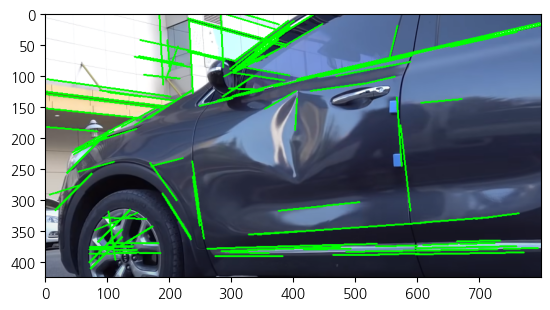

In [46]:
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 60, minLineLength=50, maxLineGap=10)

line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))

[[  0.   0.   0. ...  -2.   0.   0.]
 [  0.   0.   0. ...  -7.  -3.   0.]
 [  0.   0.   0. ... -18. -12.   0.]
 ...
 [  0.  19.  -1. ...   0.   0.   0.]
 [  0.  42.  54. ...   0.   0.   0.]
 [  0.  52.  78. ...   0.   0.   0.]]


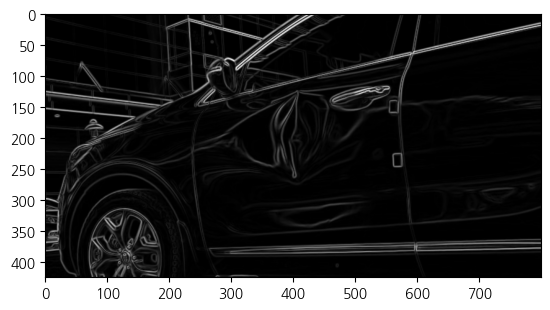

In [47]:
# Sobel 필터를 이용해 경계의 기울기 강조
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
print(sobelx)

# 기울기의 크기 계산
magnitude = np.sqrt(sobelx**2 + sobely**2)
magnitude = np.uint8(255 * magnitude / np.max(magnitude))

plt.imshow(magnitude, cmap='gray')